# COS30019 Assignment 2B: Traffic Flow Prediction

In [1]:
# install required libraries
!pip install xlrd scikit-learn tensorflow -q

In [2]:
# upload dataset and set filepath
from google.colab import files
uploaded = files.upload()
FILEPATH = list(uploaded.keys())[0]
print('Using:', FILEPATH)

ModuleNotFoundError: No module named 'google'

In [ ]:
# imports and constants
import os
import pickle
import xlrd
import numpy as np
import pandas as pd
import datetime
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from tensorflow.keras import Input
from tensorflow.keras.callbacks import EarlyStopping

LOOKBACK = 12 # use last 12 intervals (3 hours) to predict the next one
HORIZON = 1 # predict 1 step ahead (next 15 minutes)
TEST_DAYS = 6 # hold out last 6 days of October for testing
EPOCHS = 30 # max training passes (early stopping usually cuts this short)
BATCH = 32 # samples processed before updating model weights

print('TF version:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))

TF version: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 1. Preprocessing

In [ ]:
def load_raw(filepath):
    # opens the XLS file and reads every row from the Data sheet
    # each row = one detector at one intersection on one day
    # with 96 traffic readings (V00-V95), one per 15-min interval
    wb = xlrd.open_workbook(filepath)
    sh = wb.sheet_by_name('Data')
    rows = []
    for r in range(2, sh.nrows): # skip 2 header rows
        row = sh.row_values(r)
        # column 9 is the date stored as an Excel serial number, convert to real date
        dt = xlrd.xldate_as_datetime(row[9], wb.datemode).date()
        rows.append({
            'scats_id': str(row[0]).strip(),
            'location': str(row[1]).strip(),
            'lat': float(row[3]),
            'lon': float(row[4]),
            'date': dt,
            'readings': [float(v) for v in row[10:106]]
        })
    return rows

In [ ]:
def build_aggregated_df(rows):
    # each intersection has up to 4 detectors (one per road direction: N, S, E, W)
    # expand the 96 readings per row into individual timestep records
    # then sum all detector directions to get total flow per intersection per timestep
    records = []
    for row in rows:
        for i, val in enumerate(row['readings']):
            records.append({
                'scats_id': row['scats_id'],
                'lat': row['lat'],
                'lon': row['lon'],
                'date': row['date'],
                'interval': i,
                'flow': val
            })
    df = pd.DataFrame(records)
    # sum flow across all directions, average the lat/lon per site
    flow_agg = df.groupby(['scats_id', 'date', 'interval'])['flow'].sum().reset_index()
    coord_agg = df.groupby('scats_id')[['lat', 'lon']].mean().reset_index()
    agg = flow_agg.merge(coord_agg, on='scats_id')
    agg = agg.sort_values(['scats_id', 'date', 'interval']).reset_index(drop=True)
    return agg

In [ ]:
def make_sequences(values, dates, lookback=12, horizon=1):
    # creates sliding window sequences for the model
    # each sequence: use `lookback` steps as input X, predict next `horizon` steps as y
    # skips any window that spans a missing day to avoid corrupted sequences
    X, y = [], []
    for i in range(len(values) - lookback - horizon + 1):
        window_dates = dates[i:i + lookback + horizon]
        has_gap = False
        for j in range(1, len(window_dates)):
            if (window_dates[j] - window_dates[j-1]).days > 1:
                has_gap = True
                break
        if not has_gap:
            X.append(values[i:i + lookback])
            y.append(values[i + lookback:i + lookback + horizon])
    return np.array(X), np.array(y)

In [ ]:
def build_dataset(filepath, lookback=LOOKBACK, horizon=HORIZON, test_days=TEST_DAYS):
    print('Loading raw data...')
    rows = load_raw(filepath)
    print(f'Loaded {len(rows)} detector-day records')

    agg = build_aggregated_df(rows)

    # time-based split: last 6 days = test, everything before = train
    # done BEFORE making sequences to prevent future data leaking into training
    all_dates = sorted(agg['date'].unique())
    cutoff = all_dates[-test_days]
    print(f'Train: {all_dates[0]} to {all_dates[-test_days-1]}, Test: {cutoff} to {all_dates[-1]}')

    train_X_all, train_y_all, test_X_all, test_y_all = [], [], [], []
    scalers, coords = {}, {}

    for site_id, group in agg.groupby('scats_id'):
        # store lat/lon for each site, used later to calculate road distances
        coords[site_id] = (group['lat'].iloc[0], group['lon'].iloc[0])

        values = group['flow'].values.reshape(-1, 1).astype(np.float32)

        # assign each reading its actual date (96 readings per day)
        # needed so make_sequences can detect gaps between days
        date_per_step = []
        for d in group['date'].unique():
            date_per_step.extend([datetime.date.fromisoformat(str(d))] * 96)
        date_per_step = date_per_step[:len(values)]

        # normalise each site independently to 0-1
        # different sites have very different traffic volumes so we scale per site
        scaler = MinMaxScaler(feature_range=(0, 1))
        scaled = scaler.fit_transform(values).flatten()
        scalers[site_id] = scaler

        # split values and dates by the cutoff date
        train_mask = [d < cutoff for d in date_per_step]
        test_mask = [d >= cutoff for d in date_per_step]
        train_vals = scaled[train_mask]
        train_dates = [d for d, m in zip(date_per_step, train_mask) if m]
        test_vals = scaled[test_mask]
        test_dates = [d for d, m in zip(date_per_step, test_mask) if m]

        Xt, yt = make_sequences(train_vals, train_dates, lookback, horizon)
        Xv, yv = make_sequences(test_vals, test_dates, lookback, horizon)

        if len(Xt) > 0:
            train_X_all.append(Xt)
            train_y_all.append(yt)
        if len(Xv) > 0:
            test_X_all.append(Xv)
            test_y_all.append(yv)

    # combine all sites and reshape to (samples, timesteps, features) for LSTM/GRU input
    X_train = np.concatenate(train_X_all).reshape(-1, lookback, 1)
    y_train = np.concatenate(train_y_all)
    X_test = np.concatenate(test_X_all).reshape(-1, lookback, 1)
    y_test = np.concatenate(test_y_all)

    print(f'X_train: {X_train.shape}, X_test: {X_test.shape}')
    print(f'Sites: {len(scalers)}, zero values in raw data: {(agg["flow"]==0).sum()}')
    return X_train, X_test, y_train, y_test, scalers, coords, agg

# run preprocessing
X_train, X_test, y_train, y_test, scalers, coords, agg = build_dataset(FILEPATH, LOOKBACK, HORIZON, TEST_DAYS)

Loading raw data...
Loaded 4192 detector-day records
Train: 2006-10-01 to 2006-10-25, Test: 2006-10-26 to 2006-10-31
X_train: (94056, 12, 1), X_test: (21120, 12, 1)
Sites: 40, zero values in raw data: 94


## 2. Models

In [ ]:
def run_lstm(X_train, X_test, y_train, y_test, scalers):
    model = Sequential()
    model.add(Input(shape=(12, 1)))
    model.add(LSTM(50))
    model.add(Dense(1))

    model.compile(optimizer='adam', loss='mse')

    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True
    )

    # train the model, save history for loss curve plots
    history = model.fit(
        X_train, y_train,
        epochs=EPOCHS,
        batch_size=BATCH,
        validation_split=0.2,
        callbacks=[early_stop]
    )

    predictions = model.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))

    print('LSTM MAE:', mae)
    print('LSTM RMSE:', rmse)

    # save trained model so it can be loaded later without retraining
    os.makedirs('saved_models', exist_ok=True)
    model.save('saved_models/lstm_model.h5')
    print('Saved saved_models/lstm_model.h5')

    # return model and history so evaluate can plot loss curves and predictions
    return model, predictions, history, mae, rmse

# run LSTM
lstm_model, lstm_preds, lstm_history, lstm_mae, lstm_rmse = run_lstm(X_train, X_test, y_train, y_test, scalers)

Epoch 1/30
2352/2352 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step - loss: 0.0049 - val_loss: 0.0022
Epoch 2/30
2352/2352 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - loss: 0.0025 - val_loss: 0.0021
Epoch 3/30
2352/2352 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - loss: 0.0024 - val_loss: 0.0021
Epoch 4/30
2352/2352 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - loss: 0.0024 - val_loss: 0.0021
Epoch 5/30
2352/2352 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - loss: 0.0024 - val_loss: 0.0021
Epoch 6/30
2352/2352 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - loss: 0.0024 - val_loss: 0.0020
Epoch 7/30
2352/2352 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - loss: 0.0023 - val_loss: 0.0020
Epoch 8/30
2352/2352 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - loss: 0.0023 - val_loss: 0.0020
Epoch 9/30
2352/2352 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - loss: 0.0023 - val_loss: 0.0020
Epoch 10/30
2352/2352 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - loss: 0.0023 - val_loss: 0.0020
Epoch 11/30
2352/2352 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - loss: 0.0023 - val_loss: 0.0020
Epoch 12/30
2352/23

LSTM MAE: 0.032486770302057266
LSTM RMSE: 0.04688857050996083
Saved saved_models/lstm_model.h5


In [ ]:
def run_gru(X_train, X_test, y_train, y_test, scalers):
    model = Sequential()
    model.add(Input(shape=(12, 1)))
    model.add(GRU(50))
    model.add(Dense(1))

    model.compile(
        optimizer='adam',
        loss='mse'
    )

    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True
    )

    # train the model, save history for loss curve plots
    history = model.fit(
        X_train, y_train,
        epochs=EPOCHS,
        batch_size=BATCH,
        validation_split=0.2,
        callbacks=[early_stop]
    )

    predictions = model.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))

    print('GRU MAE:', mae)
    print('GRU RMSE:', rmse)

    # save trained model so it can be loaded later without retraining
    os.makedirs('saved_models', exist_ok=True)
    model.save('saved_models/gru_model.h5')
    print('Saved saved_models/gru_model.h5')

    # return model and history so evaluate can plot loss curves and predictions
    return model, predictions, history, mae, rmse

# run GRU
gru_model, gru_preds, gru_history, gru_mae, gru_rmse = run_gru(X_train, X_test, y_train, y_test, scalers)

Epoch 1/30
2352/2352 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - loss: 0.0044 - val_loss: 0.0022
Epoch 2/30
2352/2352 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - loss: 0.0025 - val_loss: 0.0022
Epoch 3/30
2352/2352 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - loss: 0.0025 - val_loss: 0.0021
Epoch 4/30
2352/2352 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - loss: 0.0024 - val_loss: 0.0020
Epoch 5/30
2352/2352 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - loss: 0.0024 - val_loss: 0.0023
Epoch 6/30
2352/2352 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - loss: 0.0024 - val_loss: 0.0022
Epoch 7/30
2352/2352 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - loss: 0.0023 - val_loss: 0.0021
660/660 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


GRU MAE: 0.03316524252295494
GRU RMSE: 0.047643259204748344
Saved saved_models/gru_model.h5


## 3. Results Summary

In [ ]:
print('Traffic Data')
print('Max traffic:', round(agg['flow'].max(), 2))
print('Average traffic:', round(agg['flow'].mean(), 2))

print('\nModel Results')
print('LSTM -> MAE:', round(lstm_mae, 5), '| RMSE:', round(lstm_rmse, 5))
print('GRU  -> MAE:', round(gru_mae, 5), '| RMSE:', round(gru_rmse, 5))

Traffic Data
Max traffic: 1409.0
Average traffic: 360.24

Model Results
LSTM -> MAE: 0.03249 | RMSE: 0.04689
GRU  -> MAE: 0.03317 | RMSE: 0.04764


## 4. Evaluation and Plots


Normalised Scale
LSTM: MAE=0.0325, RMSE=0.0469, MAPE=10.24%
GRU: MAE=0.0332, RMSE=0.0476, MAPE=10.55%

Real Vehicle Counts
LSTM: MAE=43.3 veh/15min, RMSE=62.5 veh/15min, MAPE=14.96%
GRU: MAE=44.2 veh/15min, RMSE=63.5 veh/15min, MAPE=15.43%


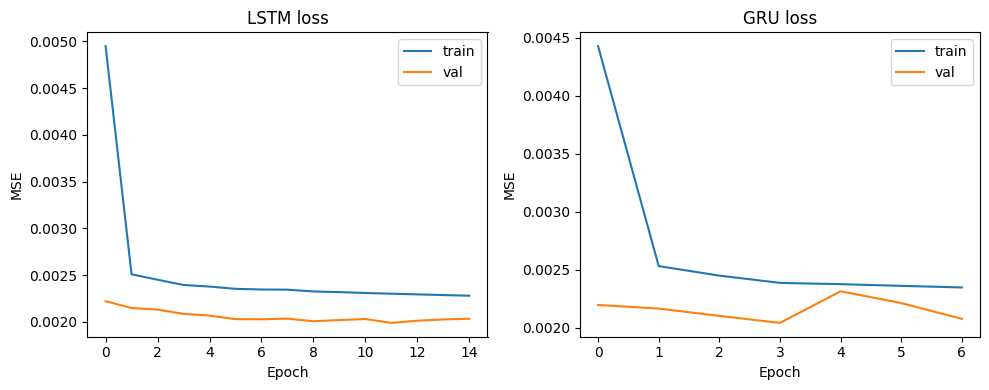

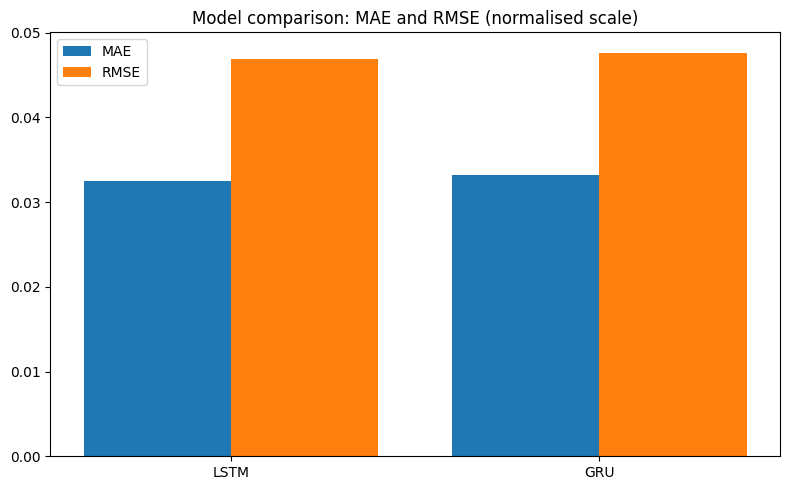

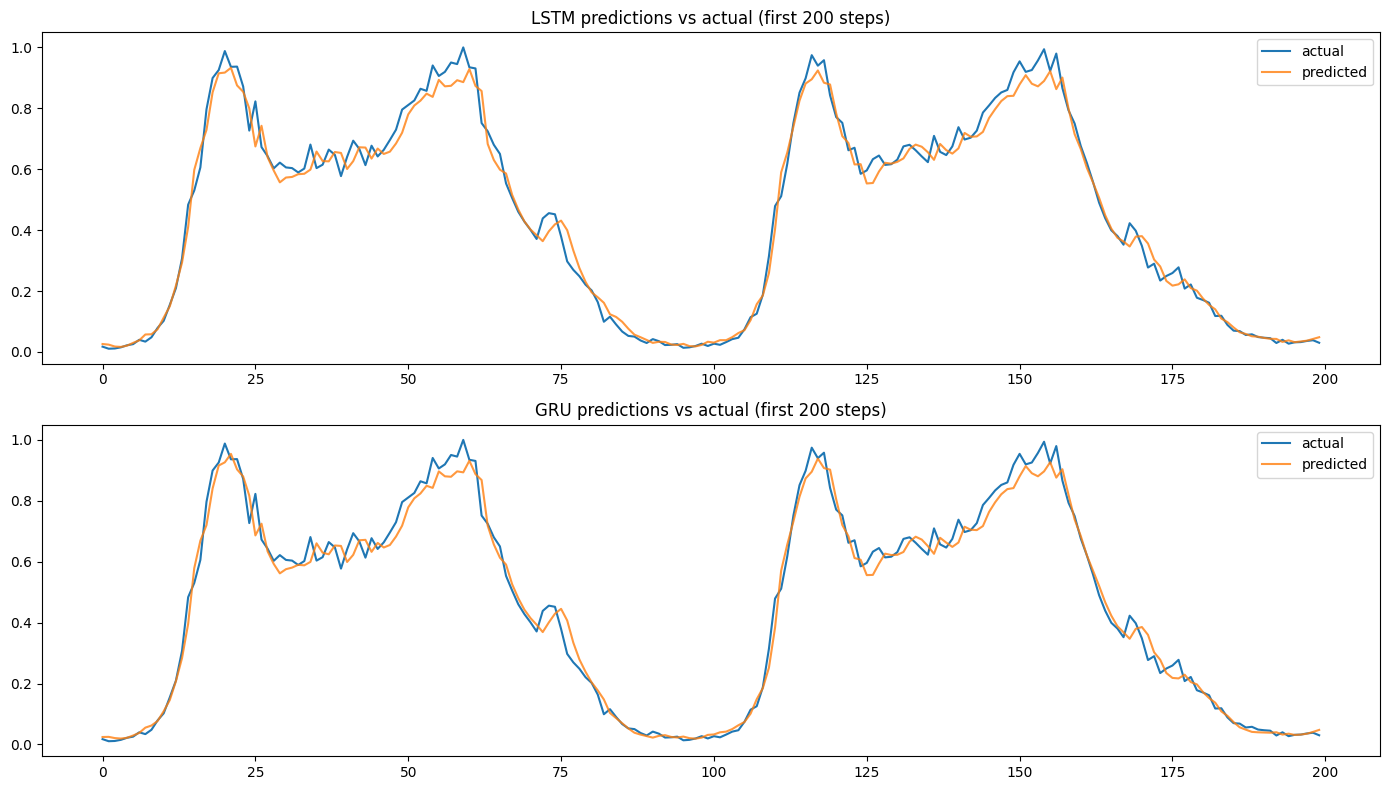

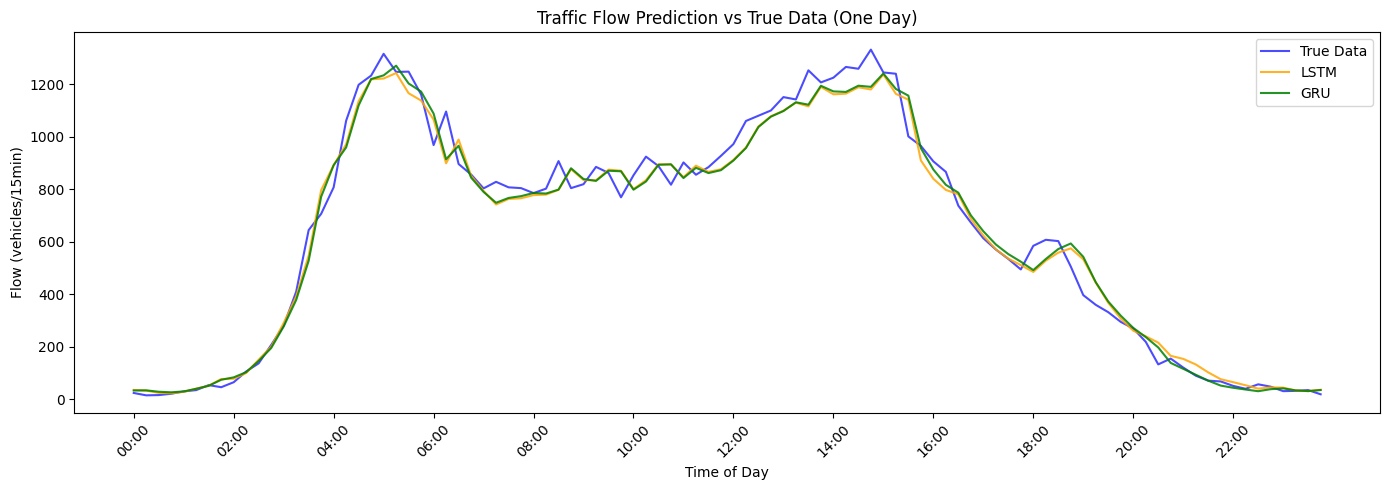

Saved plots/daily_prediction.png


In [ ]:
def plot_daily_prediction(results, y_test, scalers):
    # inverse transform predictions and actual back to real vehicle counts
    any_scaler = list(scalers.values())[0]
    actual_real = any_scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

    # generate time labels for one full day (96 intervals of 15 min)
    times = [f'{h:02d}:{m:02d}' for h in range(24) for m in (0, 15, 30, 45)]

    # use one full day worth of test data (96 steps)
    one_day = 96
    actual_day = actual_real[:one_day]

    plt.figure(figsize=(14, 5))
    plt.plot(times, actual_day, label='True Data', color='blue', alpha=0.7)

    colors = ['orange', 'green', 'red', 'purple']
    for r, color in zip(results, colors):
        preds_real = any_scaler.inverse_transform(r['predictions'].reshape(-1, 1)).flatten()
        plt.plot(times, preds_real[:one_day], label=r['name'], color=color, alpha=0.85)

    # only show every 8th label so x axis isn't crowded
    ax = plt.gca()
    ax.set_xticks(range(0, 96, 8))
    ax.set_xticklabels(times[::8], rotation=45)

    plt.title('Traffic Flow Prediction vs True Data (One Day)')
    plt.xlabel('Time of Day')
    plt.ylabel('Flow (vehicles/15min)')
    plt.legend()
    plt.tight_layout()
    plt.savefig('plots/daily_prediction.png', dpi=150)
    plt.show()
    print('Saved plots/daily_prediction.png')

def evaluate_all(results, y_test, scalers):
    # use any scaler to inverse transform back to real vehicle counts
    # all sites are normalised the same way so any scaler works as a reference
    any_scaler = list(scalers.values())[0]

    # metrics on normalised 0-1 scale
    print('\nNormalised Scale')
    for r in results:
        actual = y_test.flatten()
        preds = r['predictions'].flatten()
        # mask out near-zero values to avoid MAPE blowing up at quiet hours
        mask = actual > 0.05
        mape = np.mean(np.abs((actual[mask] - preds[mask]) / actual[mask])) * 100
        r['mape'] = mape
        print(f"{r['name']}: MAE={r['mae']:.4f}, RMSE={r['rmse']:.4f}, MAPE={mape:.2f}%")

    # inverse transform to real vehicle counts for meaningful comparison
    print('\nReal Vehicle Counts')
    for r in results:
        preds_real = any_scaler.inverse_transform(r['predictions'].reshape(-1, 1)).flatten()
        actual_real = any_scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()
        mae_real = np.mean(np.abs(actual_real - preds_real))
        rmse_real = np.sqrt(np.mean((actual_real - preds_real) ** 2))
        mask = actual_real > 5
        mape_real = np.mean(np.abs((actual_real[mask] - preds_real[mask]) / actual_real[mask])) * 100
        print(f"{r['name']}: MAE={mae_real:.1f} veh/15min, RMSE={rmse_real:.1f} veh/15min, MAPE={mape_real:.2f}%")

    os.makedirs('plots', exist_ok=True)

    # loss curves per model
    fig, axes = plt.subplots(1, len(results), figsize=(5 * len(results), 4))
    for ax, r in zip(axes, results):
        ax.plot(r['history'].history['loss'], label='train')
        ax.plot(r['history'].history['val_loss'], label='val')
        ax.set_title(f"{r['name']} loss")
        ax.set_xlabel('Epoch')
        ax.set_ylabel('MSE')
        ax.legend()
    plt.tight_layout()
    plt.savefig('plots/loss_curves.png', dpi=150)
    plt.show()

    # bar chart comparing MAE and RMSE across models
    names = [r['name'] for r in results]
    maes = [r['mae'] for r in results]
    rmses = [r['rmse'] for r in results]
    x = np.arange(len(names))
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.bar(x - 0.2, maes, 0.4, label='MAE')
    ax.bar(x + 0.2, rmses, 0.4, label='RMSE')
    ax.set_xticks(x)
    ax.set_xticklabels(names)
    ax.set_title('Model comparison: MAE and RMSE (normalised scale)')
    ax.legend()
    plt.tight_layout()
    plt.savefig('plots/model_comparison.png', dpi=150)
    plt.show()

    # predictions vs actual for first 200 test steps
    fig, axes = plt.subplots(len(results), 1, figsize=(14, 4 * len(results)))
    for ax, r in zip(axes, results):
        ax.plot(y_test.flatten()[:200], label='actual')
        ax.plot(r['predictions'].flatten()[:200], label='predicted', alpha=0.8)
        ax.set_title(f"{r['name']} predictions vs actual (first 200 steps)")
        ax.legend()
    plt.tight_layout()
    plt.savefig('plots/predictions.png', dpi=150)
    plt.show()

    # daily prediction plot comparing all models against true data
    plot_daily_prediction(results, y_test, scalers)

# run evaluation
results = [
    {'name': 'LSTM', 'predictions': lstm_preds, 'history': lstm_history, 'mae': lstm_mae, 'rmse': lstm_rmse},
    {'name': 'GRU', 'predictions': gru_preds, 'history': gru_history, 'mae': gru_mae, 'rmse': gru_rmse},
]

evaluate_all(results, y_test, scalers)

## 5. Save Scalers and Download Plots

In [ ]:
# save scalers so they can be loaded later without reprocessing
os.makedirs('saved_models', exist_ok=True)
with open('saved_models/scalers.pkl', 'wb') as f:
    pickle.dump(scalers, f)
print('Saved saved_models/scalers.pkl')

# download all saved files
for fname in [
    'saved_models/lstm_model.h5',
    'saved_models/gru_model.h5',
    'saved_models/scalers.pkl',
    'plots/loss_curves.png',
    'plots/model_comparison.png',
    'plots/predictions.png',
    'plots/daily_prediction.png'
]:
    files.download(fname)

Saved saved_models/scalers.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>